# A/B Testing Analysis

## Problem Statement
We want to test whether a new website design improves conversion rates.
## Dataset
Synthetic dataset with 10,000 users split into control and treatment groups.
## Data Exploration
(then your df.head(), info, etc.)
## Conversion Analysis
(then your groupby result)
## Hypothesis Testing
(then z-test)


In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "user_id": range(n),
    "group": np.random.choice(["control", "treatment"], n),
})

data["converted"] = np.where(
    data["group"] == "control",
    np.random.binomial(1, 0.10, n),
    np.random.binomial(1, 0.12, n)
)

data.to_csv("data/ab_test_data.csv", index=False)

In [7]:
df=pd.read_csv("data/ab_test_data.csv")
df.head()

,user_id,group,converted
0,0,control,0
1,1,treatment,0
2,2,control,0
3,3,control,0
4,4,control,0


In [8]:
df.info()
df.describe()
df["group"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    10000 non-null  int64
 1   group      10000 non-null  str  
 2   converted  10000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 234.5 KB


group
control      5013
treatment    4987
Name: count, dtype: int64

In [9]:
df.groupby("group")["converted"].mean()

group
control      0.100339
treatment    0.124724
Name: converted, dtype: float64

In [10]:
df["converted"].value_counts()

converted
0    8875
1    1125
Name: count, dtype: int64

## Initial Observations

- Dataset contains ~10,000 users
- Two groups: control and treatment
- No missing values observed
- Conversion rate is around 11%
- Groups are approximately balanced

In [11]:
df.groupby("group")["converted"].mean()

group
control      0.100339
treatment    0.124724
Name: converted, dtype: float64

## Conversion Rate Analysis

- Control group conversion rate: ~10%
- Treatment group conversion rate: ~12%
- Initial observation: Treatment group performs better

However, this difference needs to be validated using statistical testing.

In [14]:
from statsmodels.stats.proportion import proportions_ztest
control = df[df["group"] == "control"]["converted"]
treatment = df[df["group"] == "treatment"]["converted"]
success = [control.sum(), treatment.sum()]
nobs = [len(control), len(treatment)]
z_stat, p_value = proportions_ztest(success, nobs)
print("Z-stat:", z_stat)
print("P-value:", p_value)


Z-stat: -3.8586358068853492
P-value: 0.00011402170198206915


## Hypothesis Testing Result

- Z-statistic: -3.86
- P-value: 0.000114

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates that the difference in conversion rates between the control and treatment groups is statistically significant.

The treatment group shows a higher conversion rate, suggesting that the new version performs better.

### Recommendation:
Roll out the new design to all users.

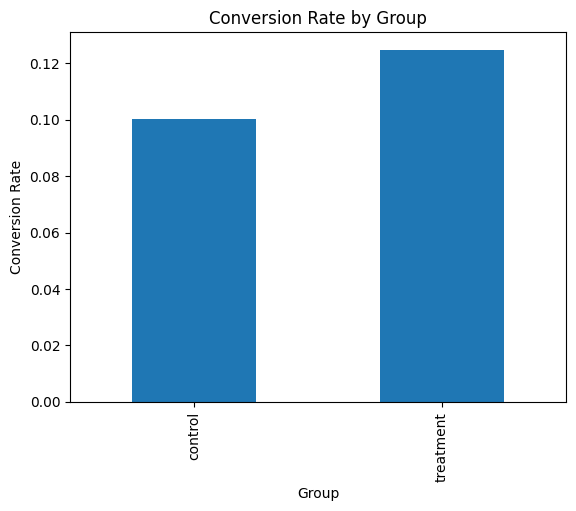

In [17]:
import matplotlib.pyplot as plt

conversion_rates = df.groupby("group")["converted"].mean()

conversion_rates.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

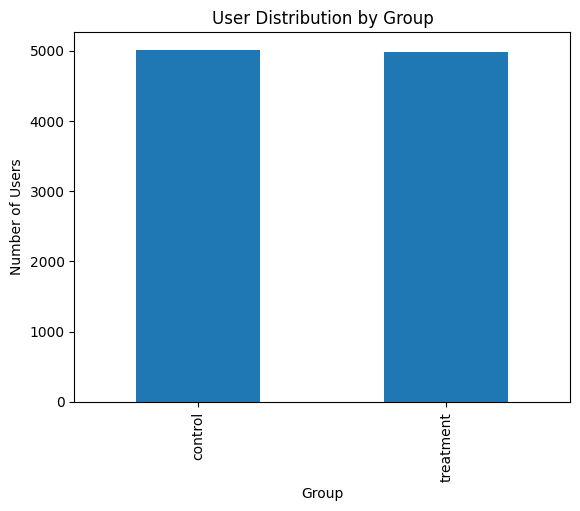

In [18]:
df["group"].value_counts().plot(kind="bar")

plt.title("User Distribution by Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.show()

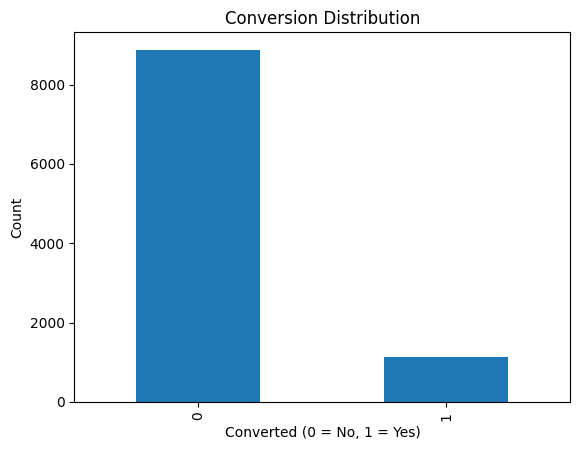

In [19]:
df["converted"].value_counts().plot(kind="bar")

plt.title("Conversion Distribution")
plt.xlabel("Converted (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

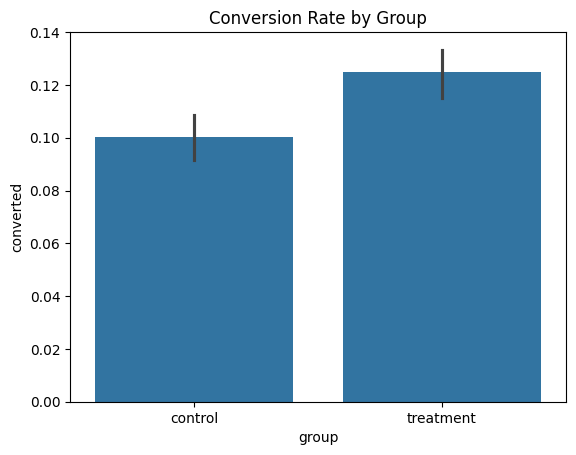

In [20]:
import seaborn as sns

sns.barplot(x="group", y="converted", data=df)

plt.title("Conversion Rate by Group")
plt.show()

## Visualization Insights

- Treatment group shows higher conversion rate than control
- User distribution is balanced across groups
- Conversion is relatively low (~10–12%), which is expected in real-world scenarios

## Final Conclusion

The treatment group showed a higher conversion rate (~12%) compared to the control group (~10%).

A two-proportion Z-test was conducted, yielding a p-value of 0.000114, which is less than the significance level of 0.05.

This indicates that the observed difference is statistically significant.

### Recommendation:
The new design should be rolled out as it improves conversion rates.